# Natural Neighbor Interpolation

## Voronoi Diagrams and Natural Neighbors

Given a set of sites $\{z_i\}_{i=1}^m$, the **Voronoi diagram** partitions the plane into cells:
$$V_i = \{x : \|x - z_i\| \leq \|x - z_j\| \text{ for all } j\}$$

When a new query point $x$ is inserted, it "steals" area from the existing Voronoi cells. The **natural neighbors** of $x$ are the sites whose cells lose area to $x$.

## Sibson's Natural Neighbor Interpolation

The **natural neighbor weight** of site $z_i$ for query $x$ is:
$$w_i(x) = \frac{|V_i \cap V(x)|}{|V(x)|}$$

where $V(x)$ is the Voronoi cell of $x$ in the augmented diagram $\{z_i\} \cup \{x\}$, and $|\cdot|$ denotes area.

The interpolant is then:
$$f^*(x) = \sum_i w_i(x) f_i$$

**Key properties**:
- $w_i(x) \geq 0$, $\sum_i w_i(x) = 1$ (**partition of unity**)
- Exact at data points: $f^*(z_i) = f_i$
- $C^1$ everywhere except at data sites
- **No bandwidth parameter** to choose — the geometry determines the weights

## Approximation via Nearest Voronoi Assignment

A fast approximation replaces exact area computation with a discrete version: for each grid point $x$, compute which data Voronoi cell it belongs to, then compute for a perturbed position $x' = x + \delta z_k$, counting how the cell membership changes over a local neighborhood.

### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d, cKDTree
from ipywidgets import interact, IntSlider

### Voronoi diagram visualization

We display the Voronoi diagram of a set of scattered points. The natural neighbor weights correspond to the fractional area stolen from each Voronoi cell when inserting a new point.

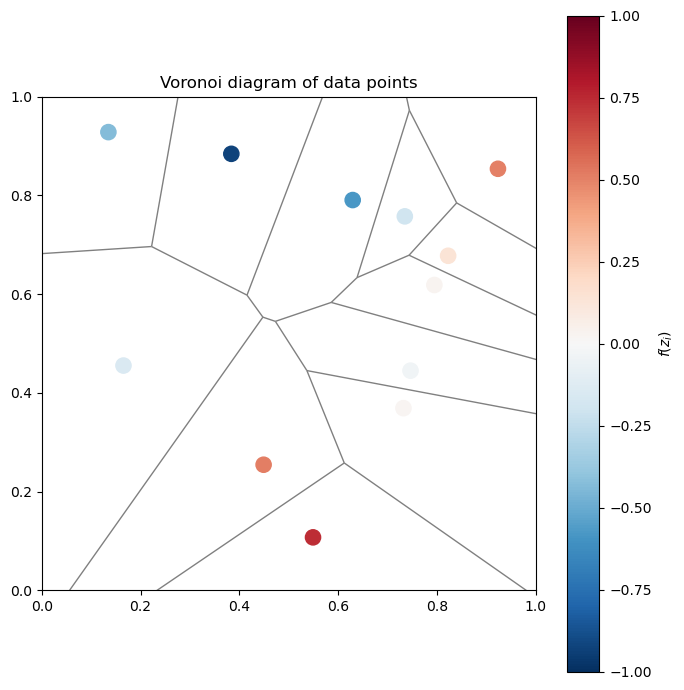

In [2]:
rng = np.random.default_rng(42)
m = 12
pts = rng.uniform(0.05, 0.95, (m, 2))
f_vals = np.sin(4 * pts[:,0]) * np.cos(4 * pts[:,1])

# Voronoi diagram (add far-away mirror points to bound the diagram)
far = 10.0
mirror = np.vstack([pts, [[-far,-far],[-far,far],[far,-far],[far,far],
                           [0.5,-far],[0.5,far],[-far,0.5],[far,0.5]]])
vor = Voronoi(mirror)

fig, ax = plt.subplots(figsize=(7, 7))
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='gray',
                line_width=1.0, point_size=0)
sc = ax.scatter(pts[:,0], pts[:,1], c=f_vals, cmap='RdBu_r', s=120,
                vmin=-1, vmax=1, zorder=5)
plt.colorbar(sc, ax=ax, label='$f(z_i)$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Voronoi diagram of data points', fontsize=12)
ax.set_aspect('equal')
plt.tight_layout(); plt.savefig('voronoi.png', dpi=100, bbox_inches='tight'); plt.show()

### Natural neighbor interpolation (discrete approximation)

We compute an approximation to Sibson weights using a fine grid. For each grid point $x$, we:
1. Find its nearest neighbor $z_{i^*}$ in the original set (standard Voronoi assignment)
2. In a small neighborhood of $x$, count how many sub-pixels belong to each data site
3. The fraction belonging to site $i$ approximates the natural neighbor weight $w_i(x)$

A simpler approximation: use the KD-tree to find the nearest data site for every point on a fine grid, then for each query point, compute the histogram of nearest-neighbor assignments over a local patch.

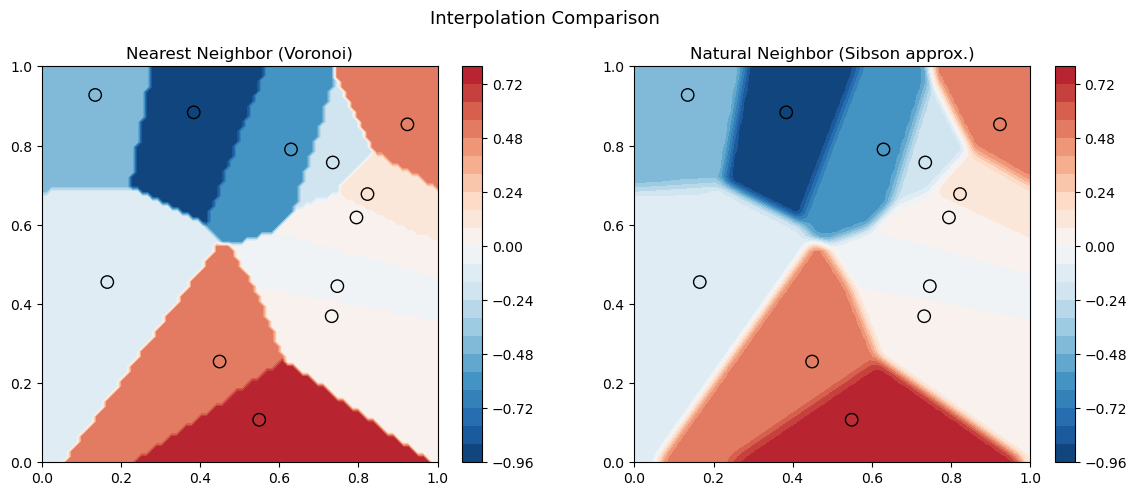

In [3]:
g = 80
gx = np.linspace(0, 1, g)
Yg, Xg = np.meshgrid(gx, gx)
grid_pts = np.column_stack([Xg.ravel(), Yg.ravel()])

# Fine grid for computing NN weights
g_fine = 400
gx_f = np.linspace(0, 1, g_fine)
Yf, Xf = np.meshgrid(gx_f, gx_f)
fine_pts = np.column_stack([Xf.ravel(), Yf.ravel()])

tree = cKDTree(pts)
# Voronoi assignment on fine grid
_, nn_idx_fine = tree.query(fine_pts)
nn_fine = nn_idx_fine.reshape(g_fine, g_fine)

# For each coarse grid point: compute natural neighbor weights
# using the local Voronoi patch method
r_nn = int(g_fine / g) + 2  # local radius in fine pixels
f_nn = np.zeros(g * g)

for p_idx in range(g * g):
    i_coarse = p_idx // g
    j_coarse = p_idx % g
    # Convert to fine-grid coords
    i_f = int(i_coarse * g_fine / g)
    j_f = int(j_coarse * g_fine / g)
    # Local patch
    i0, i1 = max(0, i_f-r_nn), min(g_fine, i_f+r_nn+1)
    j0, j1 = max(0, j_f-r_nn), min(g_fine, j_f+r_nn+1)
    patch = nn_fine[i0:i1, j0:j1].ravel()
    # Count occurrences of each neighbor
    counts = np.bincount(patch, minlength=m)
    w = counts / counts.sum()
    f_nn[p_idx] = w @ f_vals

f_nn_grid = f_nn.reshape(g, g)

# Compare with nearest-neighbor (no interpolation)
_, nn_coarse = tree.query(grid_pts)
f_voronoi = f_vals[nn_coarse].reshape(g, g)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, F, title in zip(axes,
    [f_voronoi, f_nn_grid],
    ['Nearest Neighbor (Voronoi)', 'Natural Neighbor (Sibson approx.)']):
    im = ax.contourf(Xg, Yg, F, levels=20, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.scatter(pts[:,0], pts[:,1], c=f_vals, cmap='RdBu_r', s=80,
               vmin=-1, vmax=1, edgecolors='k', zorder=5)
    ax.set_title(title); ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Interpolation Comparison', fontsize=13)
plt.tight_layout(); plt.savefig('nn_interp.png', dpi=100, bbox_inches='tight'); plt.show()

### Effect of number of data points

Natural neighbor interpolation improves with more data. We show how the interpolant quality changes with increasing $m$.

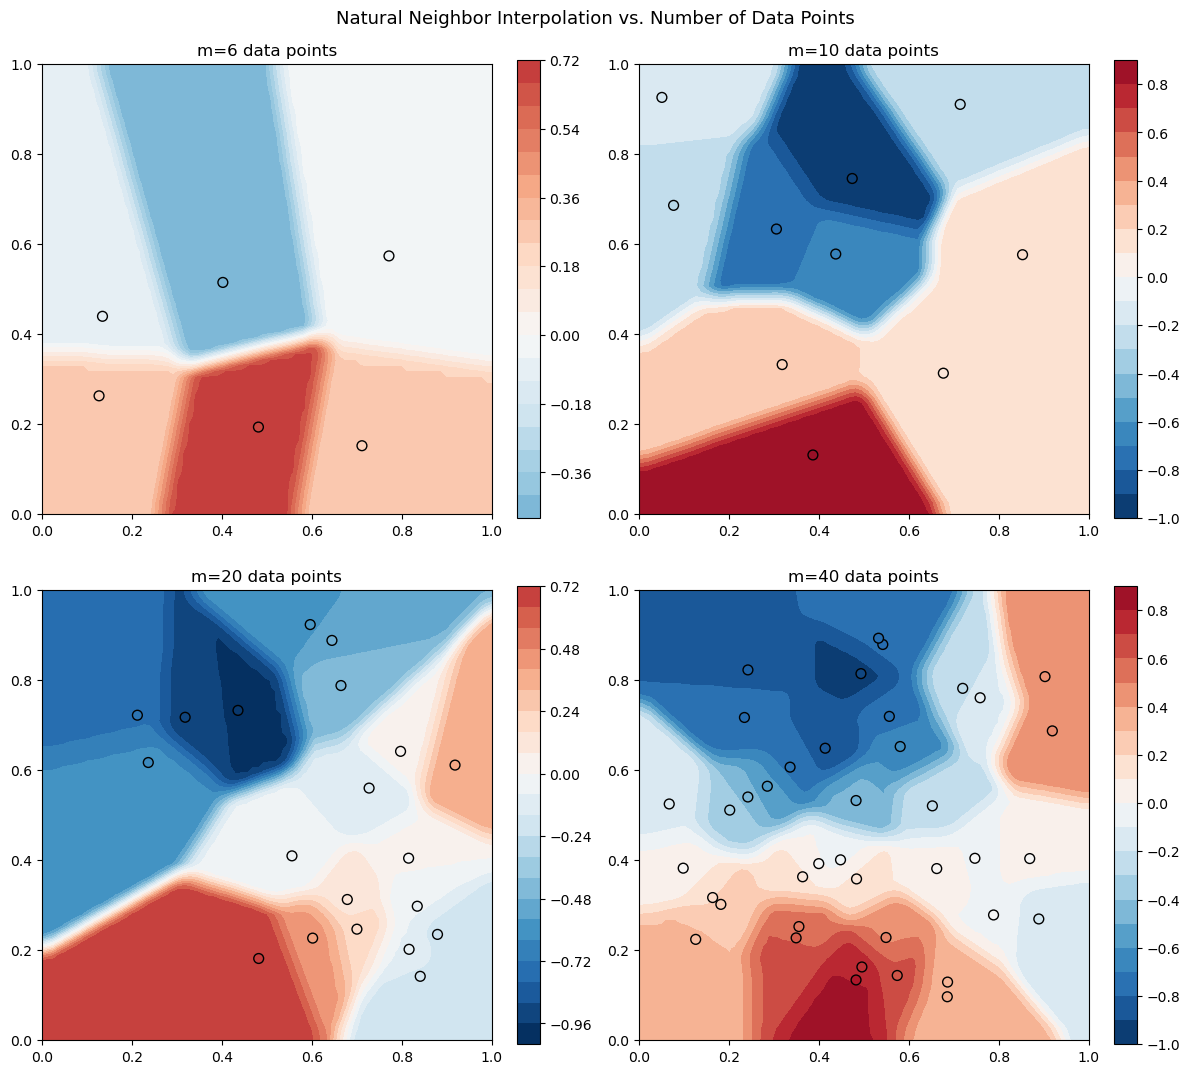

In [4]:
def nn_interpolate_fast(pts, f_vals, grid_pts, g_fine=200):
    """Fast approximation to Sibson natural neighbor interpolation."""
    gx_f = np.linspace(0, 1, g_fine)
    Yff, Xff = np.meshgrid(gx_f, gx_f)
    fine_pts_l = np.column_stack([Xff.ravel(), Yff.ravel()])
    tree_l = cKDTree(pts)
    _, nn_f = tree_l.query(fine_pts_l)
    nn_f = nn_f.reshape(g_fine, g_fine)

    g_c = int(np.sqrt(len(grid_pts)))
    r = int(g_fine / g_c) + 2
    f_out = np.zeros(len(grid_pts))
    for p_idx in range(len(grid_pts)):
        ic, jc = p_idx // g_c, p_idx % g_c
        i_f = int(ic * g_fine / g_c)
        j_f = int(jc * g_fine / g_c)
        patch = nn_f[max(0,i_f-r):min(g_fine,i_f+r+1),
                     max(0,j_f-r):min(g_fine,j_f+r+1)].ravel()
        cnts = np.bincount(patch, minlength=len(pts))
        w = cnts / max(cnts.sum(), 1)
        f_out[p_idx] = w @ f_vals
    return f_out.reshape(g_c, g_c)

m_list = [6, 10, 20, 40]
rng3 = np.random.default_rng(3)

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
for ax, m_val in zip(axes.ravel(), m_list):
    pts_k = rng3.uniform(0.05, 0.95, (m_val, 2))
    f_k = np.sin(4*pts_k[:,0]) * np.cos(4*pts_k[:,1])
    F_k = nn_interpolate_fast(pts_k, f_k, grid_pts, g_fine=160)
    im = ax.contourf(Xg, Yg, F_k, levels=20, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.scatter(pts_k[:,0], pts_k[:,1], c=f_k, cmap='RdBu_r', s=50,
               edgecolors='k', vmin=-1, vmax=1, zorder=5)
    ax.set_title(f'm={m_val} data points'); ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Natural Neighbor Interpolation vs. Number of Data Points', fontsize=13)
plt.tight_layout(); plt.savefig('nn_m_effect.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: number of points

In [ ]:
def show_nn(m_val=15, seed=42):
    rng_w = np.random.default_rng(seed)
    pts_w = rng_w.uniform(0.05, 0.95, (m_val, 2))
    f_w = np.sin(4*pts_w[:,0]) * np.cos(4*pts_w[:,1])

    tree_w = cKDTree(pts_w)
    _, nn_cw = tree_w.query(grid_pts)
    f_vor = f_w[nn_cw].reshape(g, g)
    f_nn_w = nn_interpolate_fast(pts_w, f_w, grid_pts, g_fine=160)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, F, title in zip(axes, [f_vor, f_nn_w], ['Voronoi', 'Natural Neighbor']):
        im = ax.contourf(Xg, Yg, F, levels=20, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.scatter(pts_w[:,0], pts_w[:,1], c=f_w, cmap='RdBu_r', s=60,
                   edgecolors='k', vmin=-1, vmax=1, zorder=5)
        ax.set_title(title); ax.set_aspect('equal')
        plt.colorbar(im, ax=ax)
    plt.suptitle(f'm={m_val} data points')
    plt.tight_layout(); plt.show()

interact(show_nn,
         m_val=IntSlider(min=5, max=40, step=5, value=15),
         seed=IntSlider(min=0, max=20, step=1, value=42));

### Snippet

In [5]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt

    fig, axes = _plt.subplots(1, 2, figsize=(12, 5))
    for ax, F, title in zip(axes, [f_voronoi, f_nn_grid],
                              ['Nearest Neighbor', 'Natural Neighbor']):
        im = ax.contourf(Xg, Yg, F, levels=20, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.scatter(pts[:,0], pts[:,1], c=f_vals, cmap='RdBu_r', s=80,
                   edgecolors='k', vmin=-1, vmax=1, zorder=5)
        ax.set_title(title); ax.set_aspect('equal')
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')

## Takeaways

- Natural neighbor interpolation uses Voronoi cell areas as weights — no bandwidth parameter needed.
- The weights form a **partition of unity**, ensuring the interpolant is a proper convex combination.
- The method is $C^1$ everywhere except at the data sites, combining the localization of nearest-neighbor with the smoothness of kernel interpolation.
- It handles irregular data distributions gracefully and respects the local geometry.

## Bibliography

- R. Sibson, *A brief description of natural neighbor interpolation*, Interpreting Multivariate Data, 1981.
- N. Sukumar et al., *The natural element method in solid mechanics*, IJNME 43, 1998.
- F. Aurenhammer, *Voronoi diagrams*, ACM Computing Surveys 23(3), 1991.